## Task 1: Data Analysis and Preprocessing

**objective:** Preparing clean datasets ready for modeling 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8')

print("All libraries imported successfully")

All libraries imported successfully


## Loading the Datasets
I load all 3 datasets from the `data/raw/` folder

In [ ]:
from src.data_loader import load_datasets

fraud_df, ip_country_df, credit_df = load_datasets('../data/raw')

print("All datasets loaded successfully\n")
print(f"Fraud_Data      {fraud_df.shape[0]:,} rows, {fraud_df.shape[1]} columns")
print(f"IP_Country      {ip_country_df.shape[0]:,} rows, {ip_country_df.shape[1]} columns")
print(f"CreditCard      {credit_df.shape[0]:,} rows, {credit_df.shape[1]} columns")

All datasets loaded successfully

Fraud_Data      151,112 rows, 11 columns
IP_Country      138,846 rows, 3 columns
CreditCard      284,807 rows, 31 columns


### Looking Data on:

- First few rows understand what data looks like
- Column names and data types check if types are correct
- Basic statistics understand ranges and distributions
- Missing values find what needs to be fixed

In [3]:
print("FRAUD DATA — First 5 Rows")

display(fraud_df.head())

print("FRAUD DATA — Column Names and Data Types")

fraud_df.info()


print("FRAUD DATA — Basic Statistics")


display(fraud_df.describe())

FRAUD DATA — First 5 Rows


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


FRAUD DATA — Column Names and Data Types
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB
FRAUD DATA — Basic Statistics


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


### Check missing values

In [4]:
print("MISSING VALUES — Fraud Data")


fraud_missing = pd.DataFrame({
    'Missing Count': fraud_df.isnull().sum(),
    'Missing Percent': (fraud_df.isnull().sum() / len(fraud_df) * 100).round(2)
})

print(fraud_missing[fraud_missing['Missing Count'] > 0])
print("\n No missing values" if fraud_missing['Missing Count'].sum() == 0 
      else "Missing values found — needs fixing")


print("MISSING VALUES — Credit Card Data")

credit_missing = pd.DataFrame({
    'Missing Count': credit_df.isnull().sum(),
    'Missing Percent': (credit_df.isnull().sum() / len(credit_df) * 100).round(2)
})

print(credit_missing[credit_missing['Missing Count'] > 0])
print("\n No missing values" if credit_missing['Missing Count'].sum() == 0 
      else "Missing values found — needs fixing")

MISSING VALUES — Fraud Data
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

 No missing values
MISSING VALUES — Credit Card Data
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

 No missing values


### Check Duplicates

In [ ]:
from src.preprocessor import drop_duplicates

fraud_df = drop_duplicates(fraud_df)
credit_df = drop_duplicates(credit_df)

print(f"\n Duplicates removed")
print(f"Fraud Data   Rows remaining: {fraud_df.shape[0]:,}")
print(f"Credit Card  Rows remaining: {credit_df.shape[0]:,}")

Fraud Data   Duplicate rows found: 0
Credit Card  Duplicate rows found: 1081

 Duplicates removed
Fraud Data   Rows remaining: 151,112
Credit Card  Rows remaining: 283,726


### Fixing Data Types

In [ ]:
from src.preprocessor import fix_datetime_columns

fraud_df = fix_datetime_columns(fraud_df, ['signup_time','purchase_time'])

# Verify the fix worked
print("Data types fixed\n")
print("signup_time  dtype:", fraud_df['signup_time'].dtype)
print("purchase_time dtype:", fraud_df['purchase_time'].dtype)

print("\nFraud Data — Updated Data Types:")
print(fraud_df.dtypes)

Data types fixed

signup_time  dtype: datetime64[us]
purchase_time dtype: datetime64[us]

Fraud Data — Updated Data Types:
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object


## Exploratory Data Analysis (EDA)
I explore the data visually to understand
- Distribution of key variables
- Relationship between features and fraud
- Class imbalance in both datasets

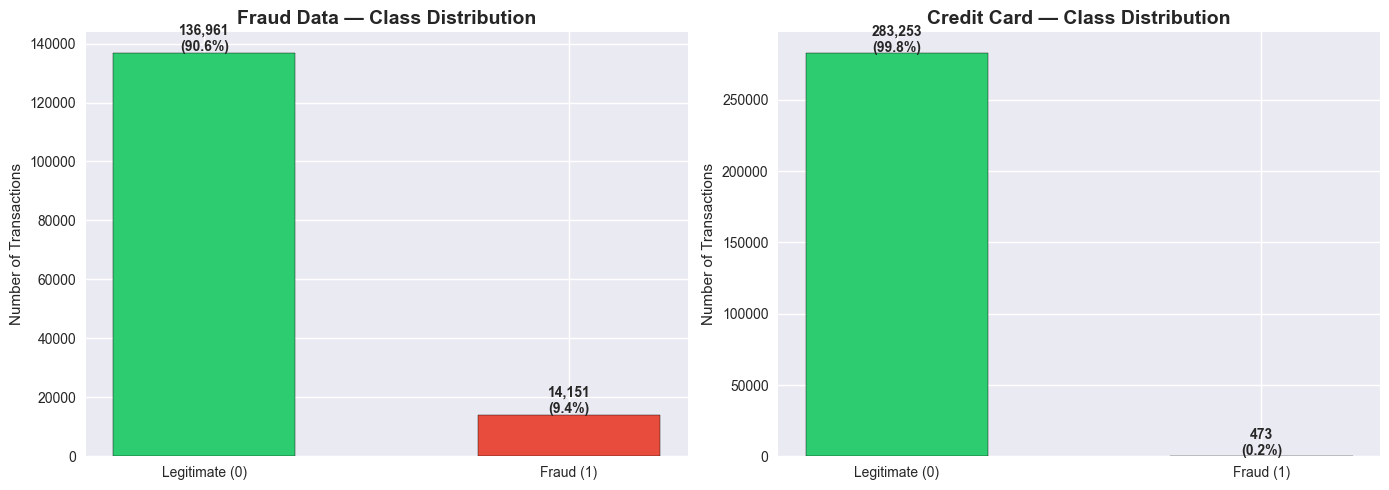

FRAUD DATA — Class Distribution
  Legitimate: 136,961 (90.64%)
  Fraud: 14,151 (9.36%)
CREDIT CARD — Class Distribution
  Legitimate: 283,253 (99.83%)
  Fraud: 473 (0.17%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = fraud_df['class'].value_counts()


fraud_pct = fraud_df['class'].value_counts(normalize=True) * 100

axes[0].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    fraud_counts.values,
    color=['#2ecc71', '#e74c3c'],  # green for legit, red for fraud
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Fraud Data — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')


for i, (count, pct) in enumerate(zip(fraud_counts.values, fraud_pct.values)):
    axes[0].text(i, count + 500, f'{count:,}\n({pct:.1f}%)', 
                ha='center', fontweight='bold')

# Credit Card Data
credit_counts = credit_df['Class'].value_counts()
credit_pct = credit_df['Class'].value_counts(normalize=True) * 100

axes[1].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    credit_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
axes[1].set_title('Credit Card — Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')

for i, (count, pct) in enumerate(zip(credit_counts.values, credit_pct.values)):
    axes[1].text(i, count + 500, f'{count:,}\n({pct:.1f}%)', 
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("FRAUD DATA — Class Distribution")

for label, count, pct in zip(['Legitimate','Fraud'], fraud_counts.values, fraud_pct.values):
    print(f"  {label}: {count:,} ({pct:.2f}%)")


print("CREDIT CARD — Class Distribution")

for label, count, pct in zip(['Legitimate','Fraud'], credit_counts.values, credit_pct.values):
    print(f"  {label}: {count:,} ({pct:.2f}%)")

### Univariate Analysis - Key Variables Distribution

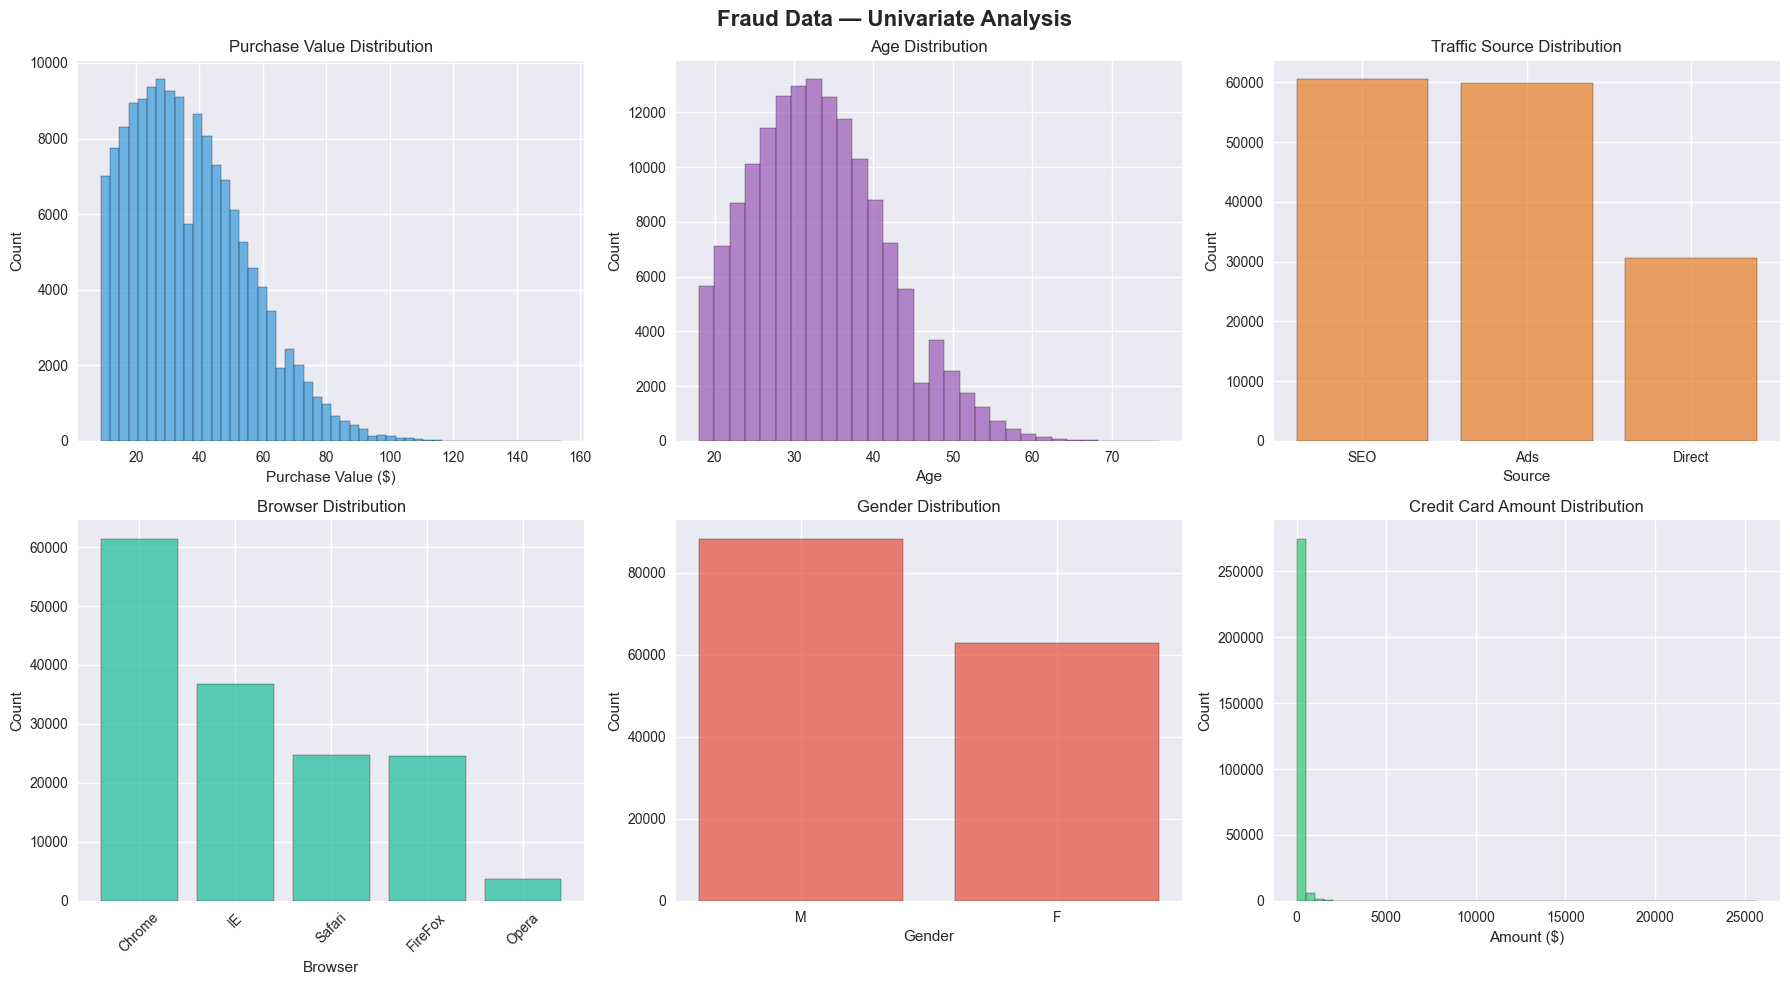

Univariate analysis complete


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud Data — Univariate Analysis', fontsize=16, fontweight='bold')

axes[0,0].hist(fraud_df['purchase_value'], bins=50, 
               color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Purchase Value Distribution')
axes[0,0].set_xlabel('Purchase Value ($)')
axes[0,0].set_ylabel('Count')


axes[0,1].hist(fraud_df['age'], bins=30, 
               color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')


source_counts = fraud_df['source'].value_counts()
axes[0,2].bar(source_counts.index, source_counts.values, 
              color='#e67e22', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Traffic Source Distribution')
axes[0,2].set_xlabel('Source')
axes[0,2].set_ylabel('Count')


browser_counts = fraud_df['browser'].value_counts()
axes[1,0].bar(browser_counts.index, browser_counts.values, 
              color='#1abc9c', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Browser Distribution')
axes[1,0].set_xlabel('Browser')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)


sex_counts = fraud_df['sex'].value_counts()
axes[1,1].bar(sex_counts.index, sex_counts.values, 
              color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Gender Distribution')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Count')


axes[1,2].hist(credit_df['Amount'], bins=50, 
               color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1,2].set_title('Credit Card Amount Distribution')
axes[1,2].set_xlabel('Amount ($)')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Univariate analysis complete")

### Bivariate Analysis - Features vs Fraud Target

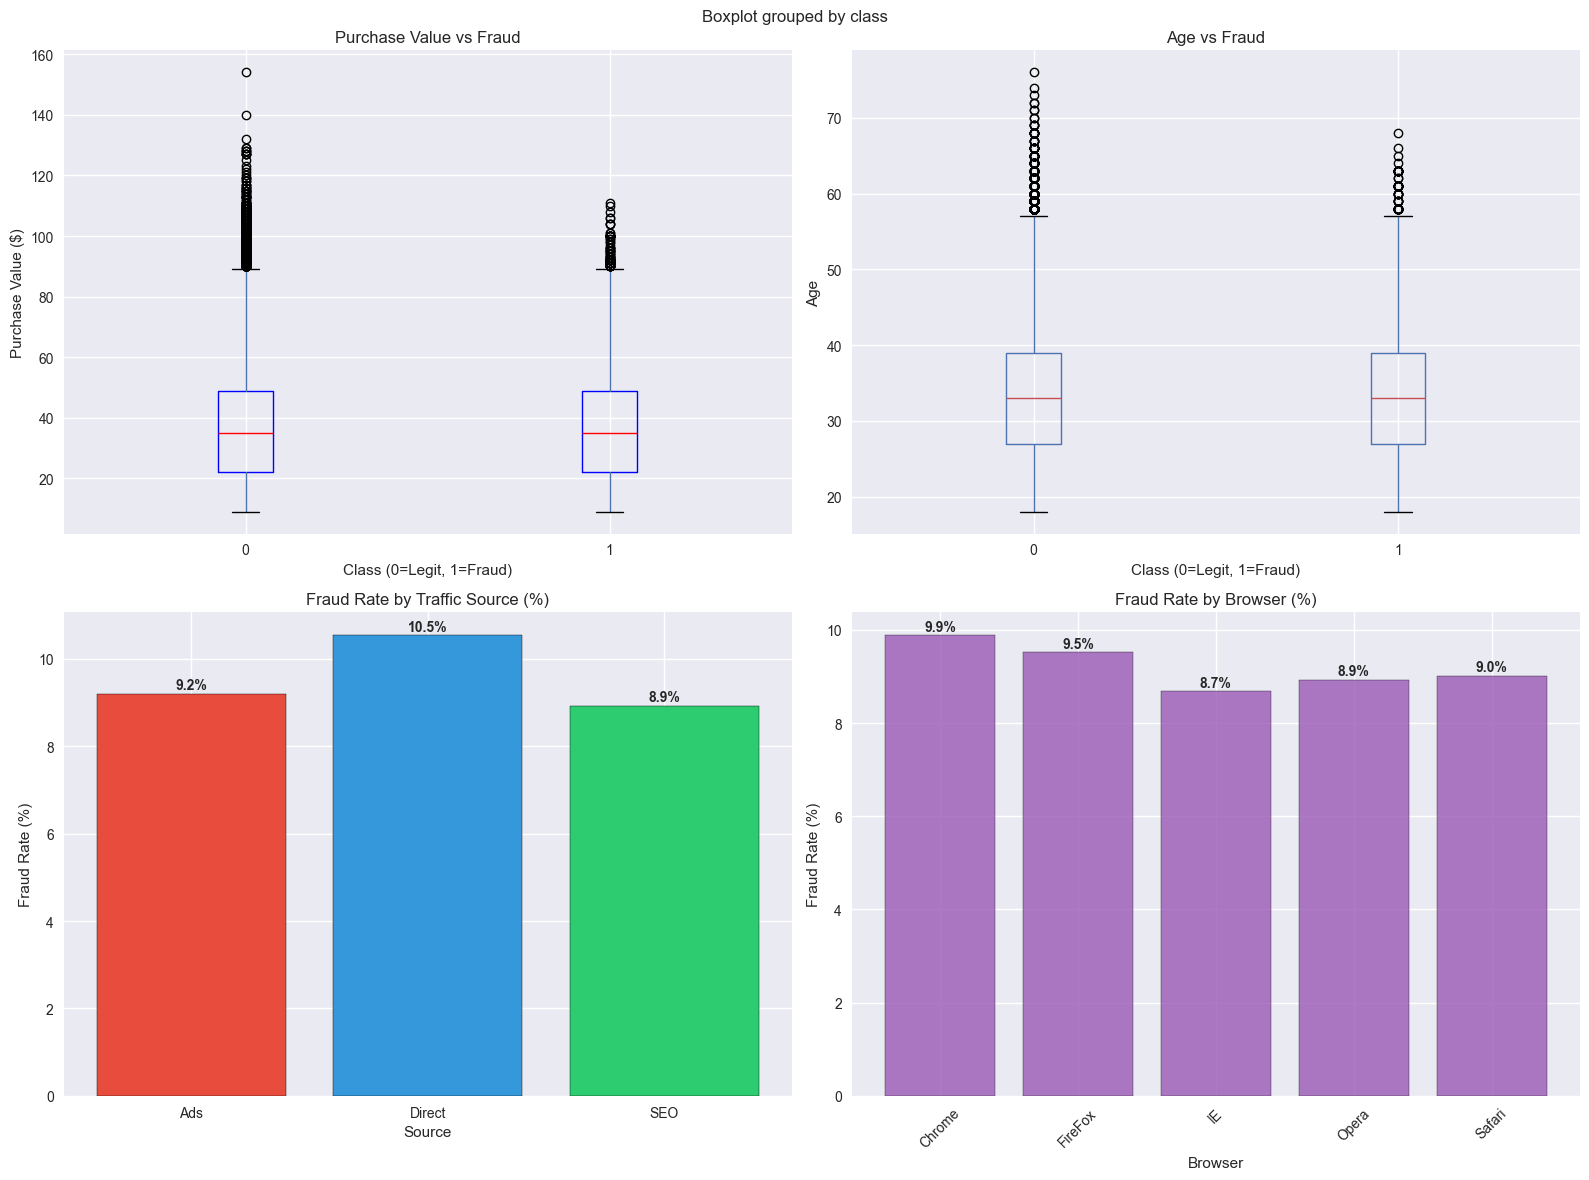

Bivariate analysis complete


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Fraud Data — Bivariate Analysis (Feature vs Fraud)', 
             fontsize=16, fontweight='bold')


fraud_df.boxplot(column='purchase_value', by='class', ax=axes[0,0],
                 boxprops=dict(color='blue'),
                 medianprops=dict(color='red'))
axes[0,0].set_title('Purchase Value vs Fraud')
axes[0,0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0,0].set_ylabel('Purchase Value ($)')


fraud_df.boxplot(column='age', by='class', ax=axes[0,1])
axes[0,1].set_title('Age vs Fraud')
axes[0,1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0,1].set_ylabel('Age')


source_fraud = fraud_df.groupby('source')['class'].mean() * 100
axes[1,0].bar(source_fraud.index, source_fraud.values, 
              color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
axes[1,0].set_title('Fraud Rate by Traffic Source (%)')
axes[1,0].set_xlabel('Source')
axes[1,0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(source_fraud.values):
    axes[1,0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')


browser_fraud = fraud_df.groupby('browser')['class'].mean() * 100
axes[1,1].bar(browser_fraud.index, browser_fraud.values, 
              color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Fraud Rate by Browser (%)')
axes[1,1].set_xlabel('Browser')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(browser_fraud.values):
    axes[1,1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bivariate analysis complete")

### Geolocation Integration
Knowing which country each transaction came from.

Converting Ip Address to Integer Format

In [ ]:
from src.preprocessor import convert_ip_to_int, ensure_ip_bounds_int

fraud_df = convert_ip_to_int(fraud_df, 'ip_address', 'ip_address_int')

ip_country_df = ensure_ip_bounds_int(ip_country_df, 'lower_bound_ip_address', 'upper_bound_ip_address')

print("IP addresses converted to integer format")
print(f"\nExample conversion:")
print(f"  Original IP  : {fraud_df['ip_address'].iloc[0]}")
print(f"  Integer IP   : {fraud_df['ip_address_int'].iloc[0]}")
print(f"\nFraud Data IP column sample:")
print(fraud_df[['ip_address', 'ip_address_int']].head())

IP addresses converted to integer format

Example conversion:
  Original IP  : 732758368.79972
  Integer IP   : 732758368

Fraud Data IP column sample:
     ip_address  ip_address_int
0  7.327584e+08       732758368
1  3.503114e+08       350311387
2  2.621474e+09      2621473820
3  3.840542e+09      3840542443
4  4.155831e+08       415583117


### Merge IP with country

In [ ]:
from src.preprocessor import merge_ip_country

merged_df = merge_ip_country(fraud_df, ip_country_df,
                            left_ip_col='ip_address_int',
                            right_lower='lower_bound_ip_address',
                            right_upper='upper_bound_ip_address')

print("Geolocation merge complete")
print(f"\nRows before merge : {fraud_df.shape[0]:,}")
print(f"Rows after merge  : {merged_df.shape[0]:,}")
print(f"Rows lost         : {fraud_df.shape[0] - merged_df.shape[0]:,}")
print(f"\nNew columns added : country")
print(f"\nSample with country:")
display(merged_df[['user_id', 'ip_address', 'ip_address_int', 'country', 'class']].head(10))

Geolocation merge complete

Rows before merge : 151,112
Rows after merge  : 129,146
Rows lost         : 21,966

New columns added : country

Sample with country:


,user_id,ip_address,ip_address_int,country,class
634,247547,1.677886e+07,16778864,Australia,0
635,220737,1.684205e+07,16842045,Thailand,0
636,390400,1.684366e+07,16843656,China,0
637,69592,1.693873e+07,16938732,China,0
638,174987,1.697198e+07,16971984,Thailand,0
639,23204,1.699555e+07,16995546,China,0
640,155230,1.709773e+07,17097732,Thailand,0
641,199369,1.712443e+07,17124428,Japan,0
642,236894,1.713459e+07,17134590,Japan,0
643,379446,1.716216e+07,17162159,Japan,0


### Analyzing Fraud By Country

TOP 10 COUNTRIES BY FRAUD RATE


,total,fraud_count,fraud_rate
country,,,
Turkmenistan,1,1,100.00
Namibia,23,10,43.48
Sri Lanka,31,13,41.94
Luxembourg,72,28,38.89
Virgin Islands (U.S.),3,1,33.33
Ecuador,106,28,26.42
Tunisia,118,31,26.27
Peru,119,31,26.05
Bolivia,53,13,24.53


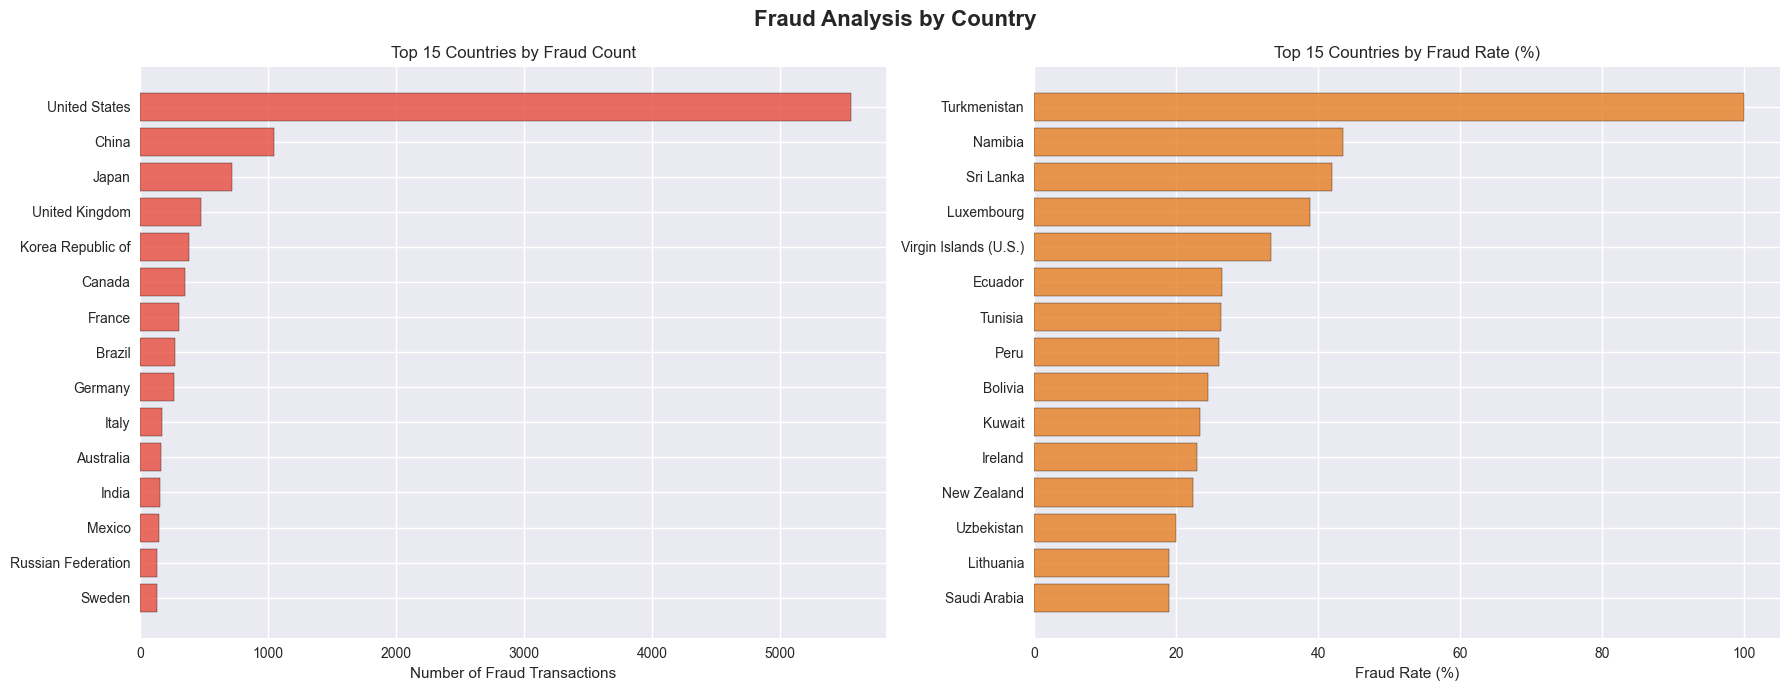

Country fraud analysis complete


In [12]:
country_total = merged_df.groupby('country').size().rename('total')


country_fraud = merged_df.groupby('country')['class'].sum().rename('fraud_count')


country_analysis = pd.concat([country_total, country_fraud], axis=1)
country_analysis['fraud_rate'] = (
    country_analysis['fraud_count'] / country_analysis['total'] * 100
).round(2)

country_analysis = country_analysis.sort_values('fraud_rate', ascending=False)

print("TOP 10 COUNTRIES BY FRAUD RATE")

display(country_analysis.head(10))

top15 = country_analysis.nlargest(15, 'fraud_count')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Fraud Analysis by Country', fontsize=16, fontweight='bold')

# Chart 1 — Top 15 countries by fraud count
axes[0].barh(top15.index, top15['fraud_count'], 
             color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('Top 15 Countries by Fraud Count')
axes[0].set_xlabel('Number of Fraud Transactions')
axes[0].invert_yaxis()  # highest on top

# Chart 2 — Top 15 countries by fraud rate
top15_rate = country_analysis.nlargest(15, 'fraud_rate')
axes[1].barh(top15_rate.index, top15_rate['fraud_rate'], 
             color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Top 15 Countries by Fraud Rate (%)')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/fraud_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Country fraud analysis complete")

### Feature Engineering

#### Time Features

In [ ]:
from src.feature_engineer import create_time_features

merged_df = create_time_features(merged_df)

print("Time features created successfully")
print("\nNew features added:")
print(merged_df[['signup_time', 'purchase_time', 
                  'time_since_signup', 'hour_of_day', 
                  'day_of_week', 'day_of_month']].head(10))

print(f"\ntime_since_signup stats:")
print(f"  Min  : {merged_df['time_since_signup'].min():.2f} hours")
print(f"  Max  : {merged_df['time_since_signup'].max():.2f} hours")
print(f"  Mean : {merged_df['time_since_signup'].mean():.2f} hours")

Time features created successfully

New features added:
            signup_time       purchase_time  time_since_signup  hour_of_day  \
634 2015-06-28 03:00:34 2015-08-09 03:57:29        1008.948611            3   
635 2015-01-28 14:21:11 2015-02-11 20:28:28         342.121389           20   
636 2015-03-19 20:49:09 2015-04-11 23:41:23         554.870556           23   
637 2015-02-24 06:11:57 2015-05-23 16:40:14        2122.471389           16   
638 2015-07-07 12:58:11 2015-11-03 04:04:30        2847.105278            4   
639 2015-06-15 21:47:39 2015-08-02 04:35:34        1134.798611            4   
640 2015-03-15 08:27:21 2015-05-21 13:55:15        1613.465000           13   
641 2015-01-17 14:38:23 2015-03-15 18:13:39        1371.587778           18   
642 2015-06-16 04:02:41 2015-07-25 01:29:33         933.447778            1   
643 2015-04-11 13:13:27 2015-07-03 22:27:10        2001.228611           22   

     day_of_week  day_of_month  
634            6             9  
635     

#### Transaction Velocity Features

In [ ]:
from src.feature_engineer import create_velocity_features

merged_df = create_velocity_features(merged_df)

print("Transaction velocity features created")
print("\nNew features:")
print(merged_df[['user_id', 'transaction_count', 
                  'transaction_velocity', 
                  'is_new_account', 'class']].head(10))

print(f"\ntransaction_count stats:")
print(f"  Min  : {merged_df['transaction_count'].min()}")
print(f"  Max  : {merged_df['transaction_count'].max()}")
print(f"  Mean : {merged_df['transaction_count'].mean():.2f}")

print(f"\nNew accounts (< 24hrs) : {merged_df['is_new_account'].sum():,}")
print(f"New account fraud rate : {merged_df[merged_df['is_new_account']==1]['class'].mean()*100:.2f}%")

Transaction velocity features created

New features:
     user_id  transaction_count  transaction_velocity  is_new_account  class
634   247547                  1              0.000990               0      0
635   220737                  1              0.002914               0      0
636   390400                  1              0.001799               0      0
637    69592                  1              0.000471               0      0
638   174987                  1              0.000351               0      0
639    23204                  1              0.000880               0      0
640   155230                  1              0.000619               0      0
641   199369                  1              0.000729               0      0
642   236894                  1              0.001070               0      0
643   379446                  1              0.000499               0      0

transaction_count stats:
  Min  : 1
  Max  : 1
  Mean : 1.00

New accounts (< 24hrs) : 7,657
New ac

### Visualizing New Features vs Fraud

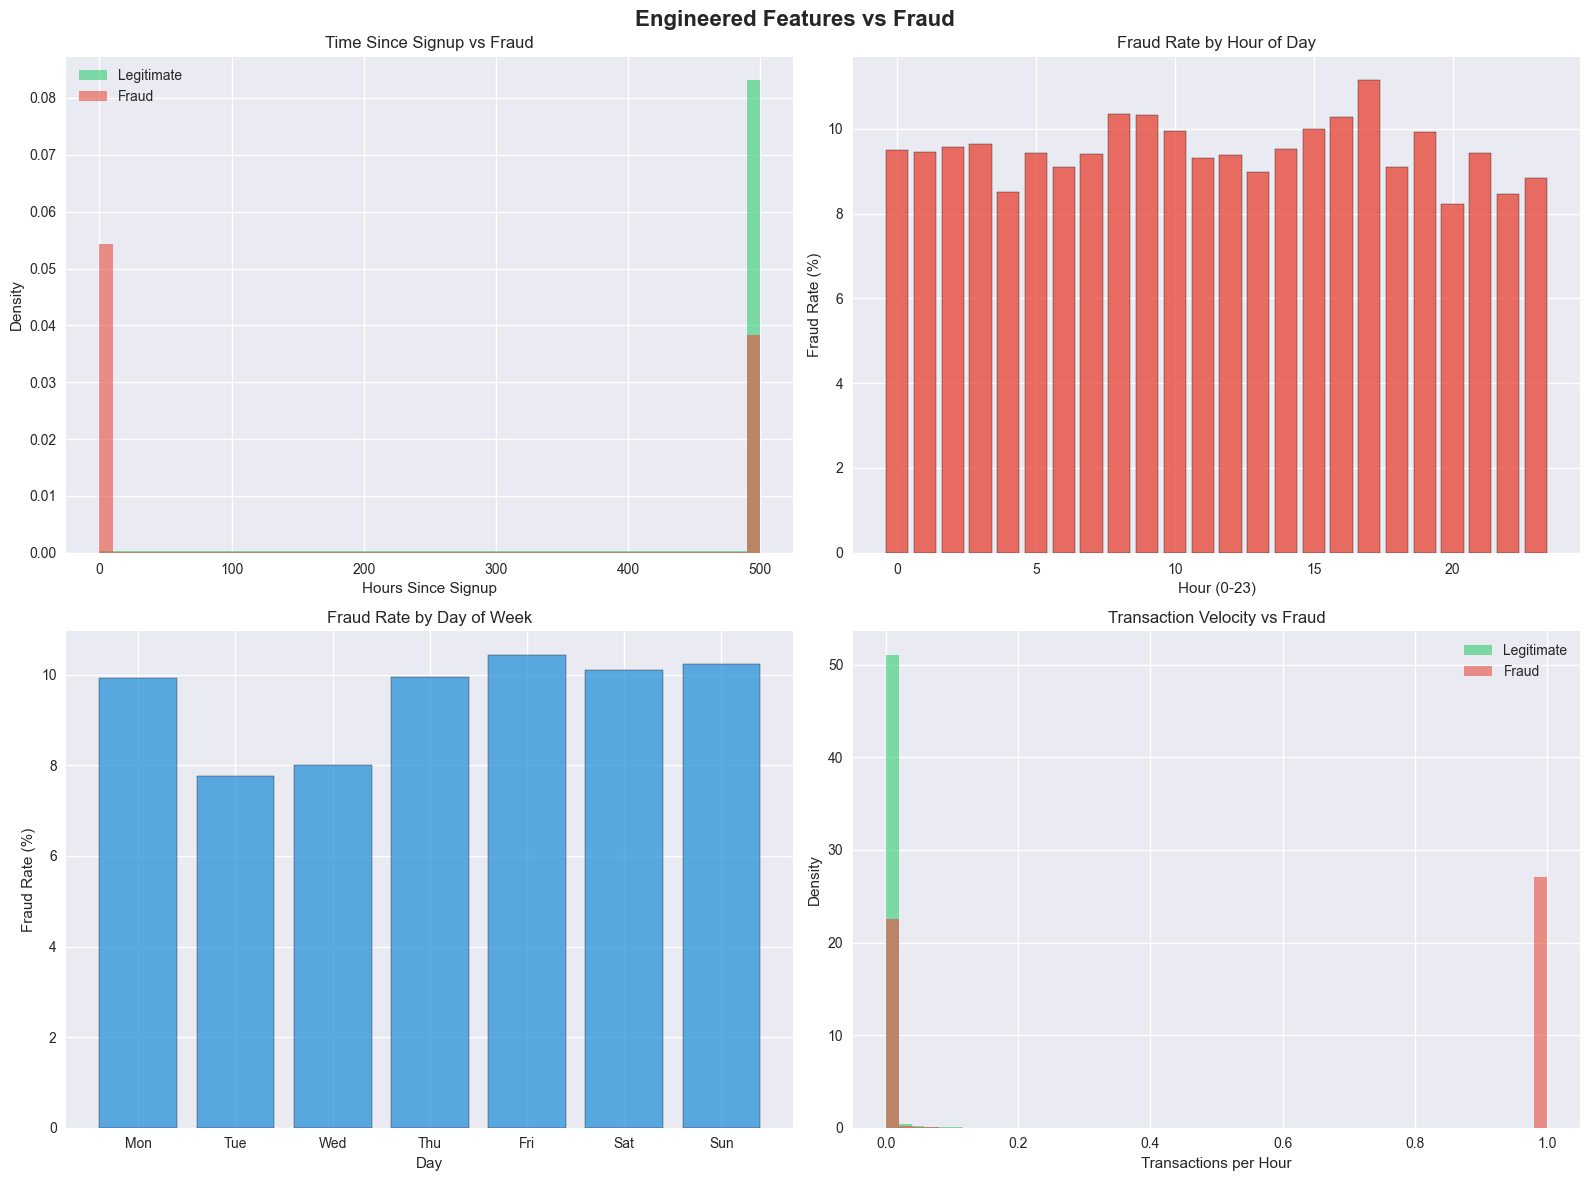

Feature visualization complete


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Engineered Features vs Fraud', fontsize=16, fontweight='bold')

# Fraudsters sign up and buy almost immediately
fraud_signup = merged_df[merged_df['class']==1]['time_since_signup']
legit_signup = merged_df[merged_df['class']==0]['time_since_signup']

axes[0,0].hist(legit_signup.clip(0, 500), bins=50, 
               alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
axes[0,0].hist(fraud_signup.clip(0, 500), bins=50, 
               alpha=0.6, color='#e74c3c', label='Fraud', density=True)
axes[0,0].set_title('Time Since Signup vs Fraud')
axes[0,0].set_xlabel('Hours Since Signup')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# Which hours have highest fraud rate?
hourly_fraud = merged_df.groupby('hour_of_day')['class'].mean() * 100
axes[0,1].bar(hourly_fraud.index, hourly_fraud.values, 
              color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Fraud Rate by Hour of Day')
axes[0,1].set_xlabel('Hour (0-23)')
axes[0,1].set_ylabel('Fraud Rate (%)')

# ---- day_of_week vs Fraud Rate ----
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_fraud = merged_df.groupby('day_of_week')['class'].mean() * 100
axes[1,0].bar(days, daily_fraud.values, 
              color='#3498db', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Fraud Rate by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Fraud Rate (%)')

# ---- transaction_velocity vs Fraud ----
fraud_vel = merged_df[merged_df['class']==1]['transaction_velocity']
legit_vel = merged_df[merged_df['class']==0]['transaction_velocity']

axes[1,1].hist(legit_vel.clip(0, 5), bins=50, 
               alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
axes[1,1].hist(fraud_vel.clip(0, 5), bins=50, 
               alpha=0.6, color='#e74c3c', label='Fraud', density=True)
axes[1,1].set_title('Transaction Velocity vs Fraud')
axes[1,1].set_xlabel('Transactions per Hour')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/processed/feature_engineering_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature visualization complete")

### Data Transformation

Preparing Feature Set for Modeling

In [16]:
columns_to_drop = [
    'user_id', 'signup_time', 'purchase_time',
    'ip_address', 'ip_address_int', 'device_id',
    'lower_bound_ip_address', 'upper_bound_ip_address'
]

# Creating modeling dataframe by dropping unused columns
model_df = merged_df.drop(columns=columns_to_drop)

print("Feature set prepared")
print(f"\nColumns kept for modeling:")
for col in model_df.columns:
    print(f" {col}")
print(f"\nShape: {model_df.shape}")

Feature set prepared

Columns kept for modeling:
 purchase_value
 source
 browser
 sex
 age
 class
 country
 time_since_signup
 hour_of_day
 day_of_week
 day_of_month
 transaction_count
 transaction_velocity
 is_new_account

Shape: (129146, 14)


### One Hot encode Categorical Features

In [17]:
categorical_columns = ['source', 'browser', 'sex', 'country']

print("Categorical columns to encode:")
for col in categorical_columns:
    unique_vals = model_df[col].nunique()
    print(f"  → {col}: {unique_vals} unique values")

model_df_encoded = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True,        
    dtype=int               
)

print(f"\n Encoding complete")
print(f"Shape before encoding : {model_df.shape}")
print(f"Shape after encoding  : {model_df_encoded.shape}")
print(f"\nNew columns added: {model_df_encoded.shape[1] - model_df.shape[1]}")
print(f"\nAll columns after encoding:")
for col in model_df_encoded.columns:
    print(f" {col}")

Categorical columns to encode:
  → source: 3 unique values
  → browser: 5 unique values
  → sex: 2 unique values
  → country: 181 unique values

 Encoding complete
Shape before encoding : (129146, 14)
Shape after encoding  : (129146, 197)

New columns added: 183

All columns after encoding:
 purchase_value
 age
 class
 time_since_signup
 hour_of_day
 day_of_week
 day_of_month
 transaction_count
 transaction_velocity
 is_new_account
 source_Direct
 source_SEO
 browser_FireFox
 browser_IE
 browser_Opera
 browser_Safari
 sex_M
 country_Albania
 country_Algeria
 country_Angola
 country_Antigua and Barbuda
 country_Argentina
 country_Armenia
 country_Australia
 country_Austria
 country_Azerbaijan
 country_Bahamas
 country_Bahrain
 country_Bangladesh
 country_Barbados
 country_Belarus
 country_Belgium
 country_Belize
 country_Benin
 country_Bermuda
 country_Bhutan
 country_Bolivia
 country_Bonaire; Sint Eustatius; Saba
 country_Bosnia and Herzegowina
 country_Botswana
 country_Brazil
 countr

### Scaling Numerical Features

In [18]:
numerical_columns = [
    'purchase_value',
    'age',
    'time_since_signup',
    'hour_of_day',
    'day_of_week',
    'day_of_month',
    'transaction_count',
    'transaction_velocity'
]

X = model_df_encoded.drop(columns=['class'])
y = model_df_encoded['class']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"\nClass distribution in y:")
print(f"  Legitimate : {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"  Fraud      : {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")

scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print(f"\n Scaling complete")
print(f"\nSample of scaled features:")
display(X[numerical_columns].head())

Features (X) shape : (129146, 196)
Target   (y) shape : (129146,)

Class distribution in y:
  Legitimate : 116,878 (90.50%)
  Fraud      : 12,268 (9.50%)

 Scaling complete

Sample of scaled features:


,purchase_value,age,time_since_signup,hour_of_day,day_of_week,day_of_month,transaction_count,transaction_velocity
634,0.549607,-0.363124,-0.413800,-1.231124,1.487911,-0.713201,0.0,-0.240153
635,-1.197335,0.101168,-1.180852,1.229002,-0.505034,-0.486095,0.0,-0.231445
636,0.385831,-0.479197,-0.936126,1.663142,0.989675,-0.486095,0.0,-0.236492
637,0.986342,-0.363124,0.867086,0.650149,0.989675,0.876539,0.0,-0.242502
638,0.767974,0.449387,1.700633,-1.086411,-1.003270,-1.394518,0.0,-0.243044


### Train Test Split

In [19]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)

print(" Data split complete")
print(f"\nTraining set   : {X_train.shape[0]:,} rows")
print(f"Testing set    : {X_test.shape[0]:,} rows")
print(f"\nTraining fraud rate : {y_train.mean()*100:.2f}%")
print(f"Testing  fraud rate : {y_test.mean()*100:.2f}%")
print(f"\n→ Fraud rate is same in both sets (stratify worked)")

 Data split complete

Training set   : 103,316 rows
Testing set    : 25,830 rows

Training fraud rate : 9.50%
Testing  fraud rate : 9.50%

→ Fraud rate is same in both sets (stratify worked)


### Handling Class Imbalance By Smote

Before SMOTE:
  Training set size  : 103,316
  Legitimate         : 93,502 (90.50%)
  Fraud              : 9,814 (9.50%)

 SMOTE applied successfully

After SMOTE:
  Training set size  : 187,004
  Legitimate         : 93,502 (50.00%)
  Fraud              : 93,502 (50.00%)


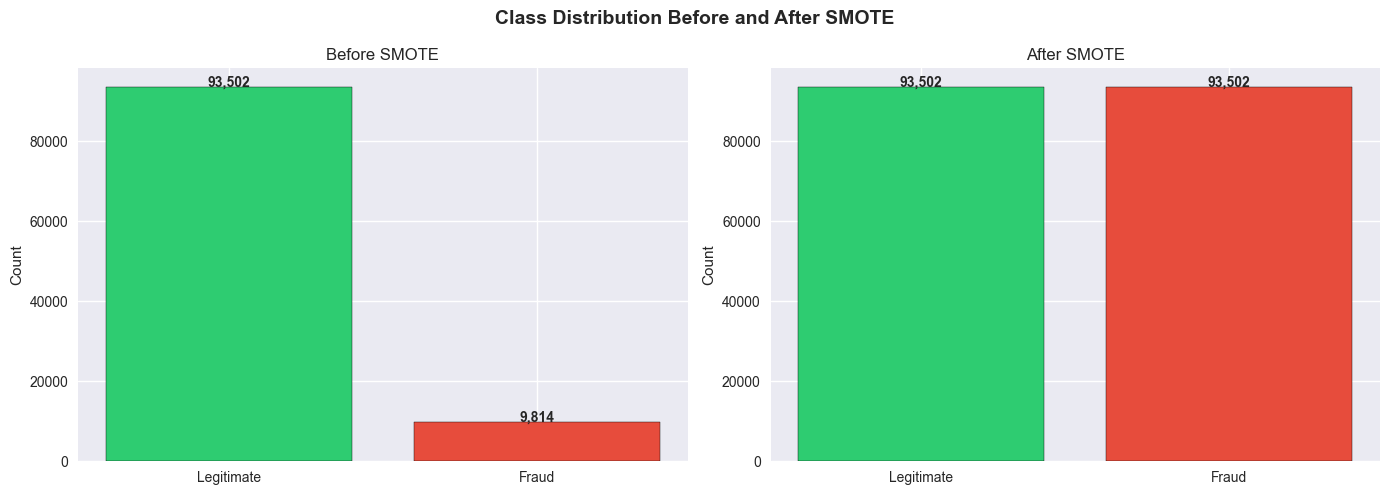

In [20]:
print("Before SMOTE:")
print(f"  Training set size  : {X_train.shape[0]:,}")
print(f"  Legitimate         : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Fraud              : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n SMOTE applied successfully")
print(f"\nAfter SMOTE:")
print(f"  Training set size  : {X_train_smote.shape[0]:,}")
print(f"  Legitimate         : {(y_train_smote==0).sum():,} ({(y_train_smote==0).mean()*100:.2f}%)")
print(f"  Fraud              : {(y_train_smote==1).sum():,} ({(y_train_smote==1).mean()*100:.2f}%)")

# Visualize before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Before and After SMOTE', 
             fontsize=14, fontweight='bold')

# Before SMOTE
before_counts = y_train.value_counts()
axes[0].bar(['Legitimate', 'Fraud'], before_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Legitimate', 'Fraud'], after_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Saving Processed Data

In [21]:
import os

os.makedirs('../data/processed', exist_ok=True)


merged_df.to_csv('../data/processed/fraud_data_processed.csv', index=False)


credit_df.to_csv('../data/processed/creditcard_processed.csv', index=False)


import numpy as np
np.save('../data/processed/X_train_smote.npy', X_train_smote)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_train_smote.npy', y_train_smote)
np.save('../data/processed/y_test.npy', y_test)

print("All processed files saved")
print("\nSaved files:")
print("  data/processed/fraud_data_processed.csv")
print("  data/processed/creditcard_processed.csv")
print("  data/processed/X_train_smote.npy")
print("  data/processed/X_test.npy")
print("  data/processed/y_train_smote.npy")
print("  data/processed/y_test.npy")

All processed files saved

Saved files:
  data/processed/fraud_data_processed.csv
  data/processed/creditcard_processed.csv
  data/processed/X_train_smote.npy
  data/processed/X_test.npy
  data/processed/y_train_smote.npy
  data/processed/y_test.npy
